TITANIC SURVIVAL PREDICTOR — COMPLETE PROJECT
#   Clean → Train → Evaluate → BigQuery → Vertex AI

STEP 0 — Install all required libraries

In [ ]:
# install all Library Required
!pip install google-cloud-bigquery pandas scikit-learn matplotlib seaborn
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install google-cloud-bigquery google-cloud-storage
!pip install google-cloud-aiplatform pandas-gbq joblib

In [ ]:
# import Libraries
from google.cloud import bigquery
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
print("-" * 55)
print("   TITANIC ML PROJECT — STARTING")
print("-" * 55)

-------------------------------------------------------
   TITANIC ML PROJECT — STARTING
-------------------------------------------------------


In [ ]:
from google.cloud import bigquery

# Construct a BigQuery client object.
client = bigquery.Client(project="titanic-498313")


STEP 1 — LOAD DATA

In [ ]:
print("\n[STEP 1] Loading data...")


[STEP 1] Loading data...


In [ ]:

# Option A: Load from seaborn (no file needed)
titanic = sns.load_dataset("titanic")

In [ ]:
# hmm based on a person information hmm predict krna chahte hii are they going to survive or not survive.
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print(f"  Shape: {titanic.shape}")
print(f"  Columns: {list(titanic.columns)}")
print(titanic.head())

  Shape: (891, 15)
  Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
titanic.drop_duplicates(inplace=True)


 STEP 2 — EXPLORE DATA (EDA)

In [ ]:
print("\n[STEP 2] Exploring data...")


[STEP 2] Exploring data...


In [ ]:
print("\n  Null values per column:")
print(titanic.isnull().sum())


  Null values per column:
survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
print("\n  Survival count:")
print(titanic["survived"].value_counts())


  Survival count:
survived
0    461
1    323
Name: count, dtype: int64


In [ ]:
print("\n  Basic statistics:")
print(titanic.describe())


  Basic statistics:
         survived      pclass         age       sibsp       parch        fare
count  784.000000  784.000000  678.000000  784.000000  784.000000  784.000000
mean     0.411990    2.243622   29.869351    0.522959    0.415816   34.711740
std      0.492507    0.855056   14.759076    0.986231    0.836922   52.160151
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    1.000000   20.000000    0.000000    0.000000    8.050000
50%      0.000000    3.000000   28.250000    0.000000    0.000000   15.900000
75%      1.000000    3.000000   39.000000    1.000000    1.000000   34.109350
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


Visualise survival by gender

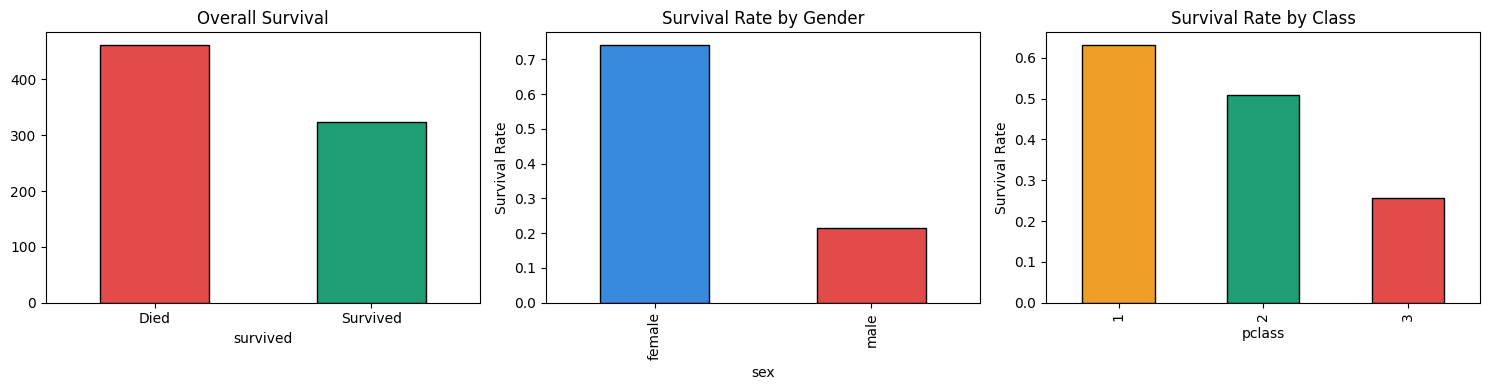

  EDA charts saved as eda_charts.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titanic["survived"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#E24B4A", "#1D9E75"], edgecolor="black"
)
axes[0].set_title("Overall Survival")
axes[0].set_xticklabels(["Died", "Survived"], rotation=0)

titanic.groupby("sex")["survived"].mean().plot(
    kind="bar", ax=axes[1], color=["#378ADD", "#E24B4A"], edgecolor="black"
)
axes[1].set_title("Survival Rate by Gender")
axes[1].set_ylabel("Survival Rate")

titanic.groupby("pclass")["survived"].mean().plot(
    kind="bar", ax=axes[2], color=["#EF9F27", "#1D9E75", "#E24B4A"], edgecolor="black"
)
axes[2].set_title("Survival Rate by Class")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=100, bbox_inches="tight")
plt.show()
print("  EDA charts saved as eda_charts.png")

STEP 3 — DATA CLEANING

In [ ]:
print("\n[STEP 3] Cleaning data...")


[STEP 3] Cleaning data...


In [ ]:
#  Select only useful features
# null value hii jooo hme fill krna hoga sabse pahle
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target   = "survived"

In [ ]:
# to fill the missing data
from sklearn.impute import SimpleImputer

# Median imputation for Age  (Handling missing data)
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# Most frequent imputation for Embarked
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [ ]:
titanic.isnull().sum() # age and embarked ke andar null value fill ho gyi hii.

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
# Select only useful features
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target   = "survived"

In [ ]:
df = titanic[features + [target]].copy()

In [ ]:
print(f"  Null values before cleaning:\n{df.isnull().sum()}")

  Null values before cleaning:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [ ]:
# Fill missing AGE with median
age_median = df["age"].median()
df["age"].fillna(age_median, inplace=True)
print(f"  Age null filled with median: {age_median:.1f}")

  Age null filled with median: 28.2


In [ ]:
# Fill missing EMBARKED with most frequent value
embarked_mode = df["embarked"].mode()[0]
df["embarked"].fillna(embarked_mode, inplace=True)
print(f"  Embarked null filled with mode: {embarked_mode}")

  Embarked null filled with mode: S


In [ ]:
# Drop rows where FARE is missing (very rare)
df.dropna(subset=["fare"], inplace=True)

print(f"\n  Null values after cleaning:\n{df.isnull().sum()}")
print(f"  Final shape: {df.shape}")


  Null values after cleaning:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64
  Final shape: (784, 8)


STEP 4 — ENCODING CATEGORICAL COLUMNS

In [ ]:
print("\n[STEP 4] Encoding categorical columns...")


[STEP 4] Encoding categorical columns...


In [ ]:
# encode krne ke liye:---
from sklearn.preprocessing import LabelEncoder

# Sex column
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Encode SEX: female=0, male=1
df["sex"] = df["sex"].map({"female": 0, "male": 1})
print("  sex encoded: female=0, male=1")

  sex encoded: female=0, male=1


In [ ]:
# Encode EMBARKED: C=0, Q=1, S=2
df["embarked"] = df["embarked"].map({"C": 0, "Q": 1, "S": 2})
print("  embarked encoded: C=0, Q=1, S=2")

print(f"\n  Sample after encoding:")
print(df.head())

  embarked encoded: C=0, Q=1, S=2

  Sample after encoding:
   pclass  sex   age  sibsp  parch     fare  embarked  survived
0       3    1  22.0      1      0   7.2500         2         0
1       1    0  38.0      1      0  71.2833         0         1
2       3    0  26.0      0      0   7.9250         2         1
3       1    0  35.0      1      0  53.1000         2         1
4       3    1  35.0      0      0   8.0500         2         0


In [ ]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


 STEP 5 — TRAIN / TEST SPLIT

In [ ]:
print("\n[STEP 5] Splitting data...")


[STEP 5] Splitting data...


In [ ]:
# now we are ready kii data ko split krna hii (X ANd Y value):---
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

X = titanic[features]
y = titanic[target]

In [ ]:
X.head()  # yaha par sari x value aa jayegi:-

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [ ]:
y.head()  # too hmare pass ye sari value aa jaygi.

,survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
# we can do train_ test_ split:--- (random testing data ke liye check kiya)---
x_train, x_test, y_train, y_test = train_test_split(
    X, y , test_size = 0.2, random_state = 42
)

In [ ]:
x_test.head()

,pclass,sex,age,sibsp,parch,fare,embarked
677,3,0,18.0,0,0,9.8417,2
668,3,1,43.0,0,0,8.0500,2
222,3,1,51.0,0,0,8.0500,2
719,3,1,33.0,0,0,7.7750,2
183,2,1,1.0,2,1,39.0000,2


In [ ]:
# similarly hmm training data ke liye also check kar sakte hii:---
x_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked
864,2,1,24.00,0,0,13.0000,2
141,3,0,22.00,0,0,7.7500,2
730,1,0,29.00,0,0,211.3375,2
56,2,0,21.00,0,0,10.5000,2
451,3,1,28.25,1,0,19.9667,2


In [ ]:
x_train.shape[0]

627

In [ ]:
x_test.shape[0]

157

2 nd way through Antrophic:--Under- Step 4 (Train, Test -split).

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures equal survival ratio in both splits
)

print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")
print(f"  Survival rate — Train: {y_train.mean():.3f}  Test: {y_test.mean():.3f}")

  Training samples : 627
  Testing  samples : 157
  Survival rate — Train: 0.411  Test: 0.414


STEP 6 — TRAIN Decision Tree MODELS

In [ ]:
print("\n[STEP 6] Training models...")



[STEP 6] Training models...


In [ ]:
#  now i am going to build Decision tree model.__:---
# Abhi model jo buid karenge uske andarkoi pruning nhi karenge:--- ( to normal ek model build karenge)---

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)

print("accuracy;", accuracy_score(y_test, y_pred))


accuracy; 0.46496815286624205


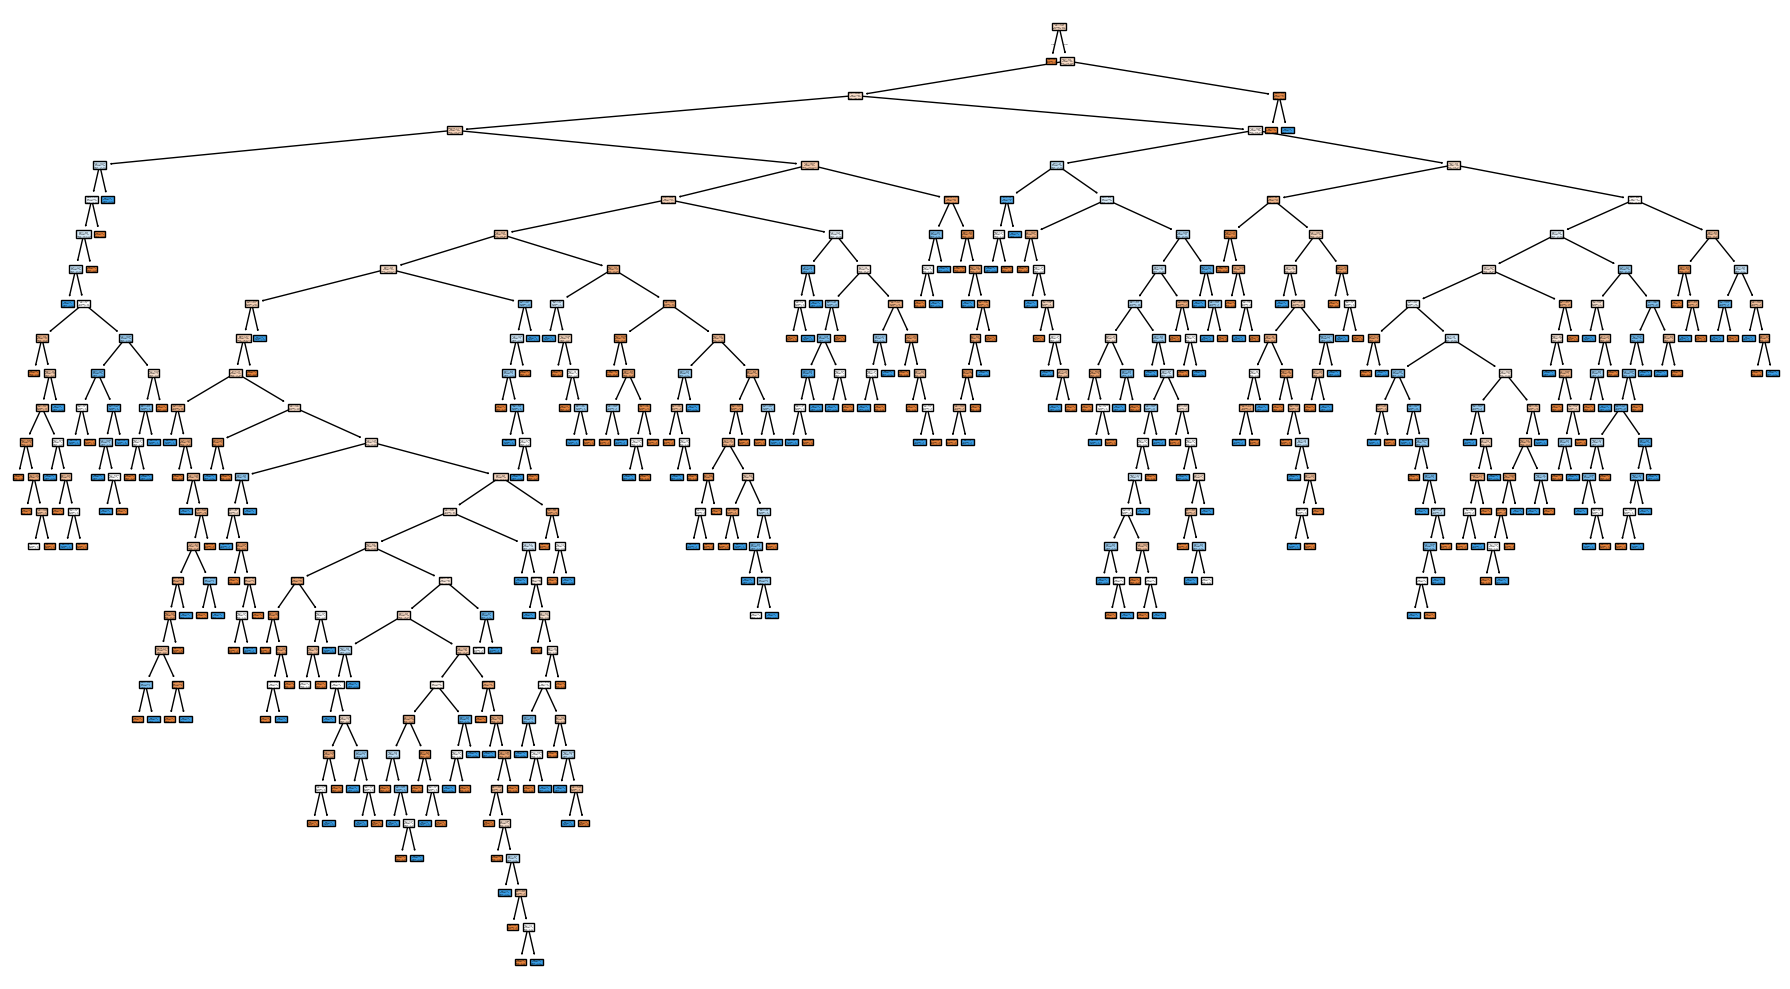

In [ ]:
# abb hmm chahe too decision tree ko plot bhii karr sakte hii:---
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True # filled mtlab hmm value ko iske andarfill krna chahte hiii.
)

plt.tight_layout()
plt.show()
# withoout any pruning hmara decision tree kaise dikh raha hii
# hmne four layers ke example liye the infact ydi hmm aur jayda fatures koo lete to hmara decision tree aur jayad dense hota.

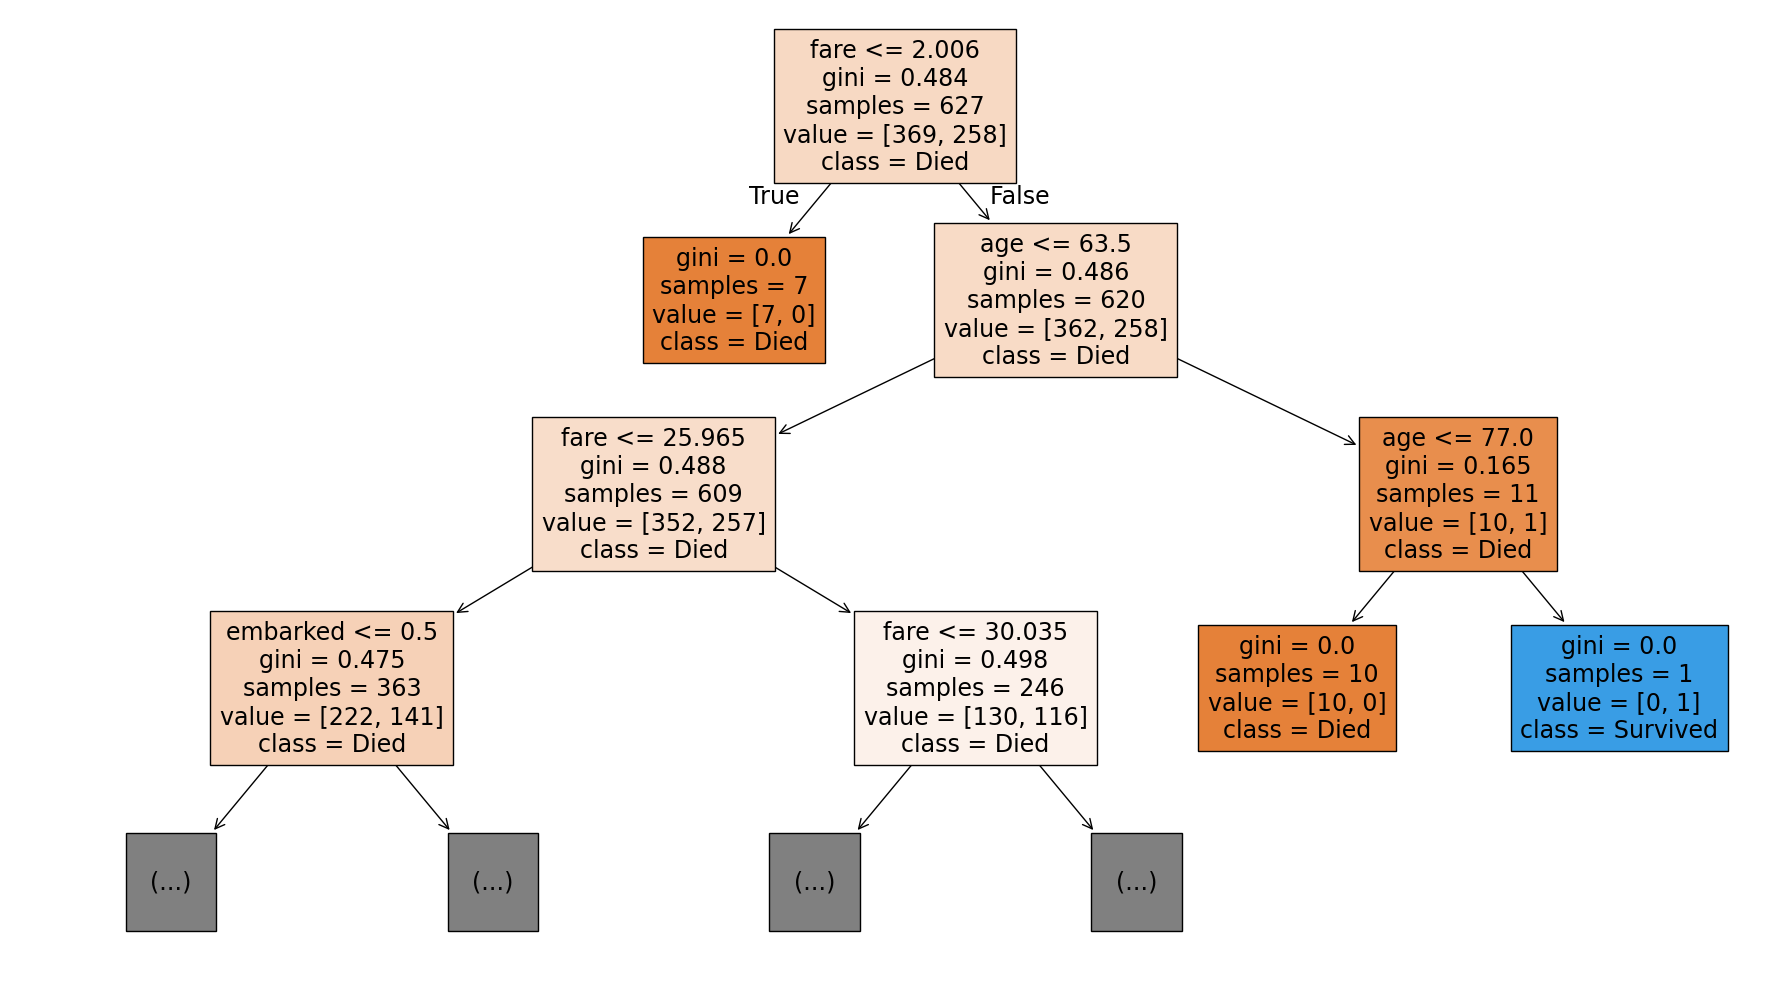

In [ ]:
 from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True ,# filled mtlab hmm value ko iske andarfill krna chahte hiii.
    max_depth= 3
)

plt.tight_layout()
plt.show()

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


STEP 6 — TRAIN MULTIPLE MODELS

In [ ]:
print("\n[STEP 6] Training models...")


[STEP 6] Training models...


  Decision Tree             Accuracy: 0.8025 (80.25%)
  Random Forest             Accuracy: 0.8344 (83.44%)
  Logistic Regression       Accuracy: 0.8217 (82.17%)
  SVM                       Accuracy: 0.6306 (63.06%)
  KNN                       Accuracy: 0.6879 (68.79%)

  Best model: Random Forest (83.44%)


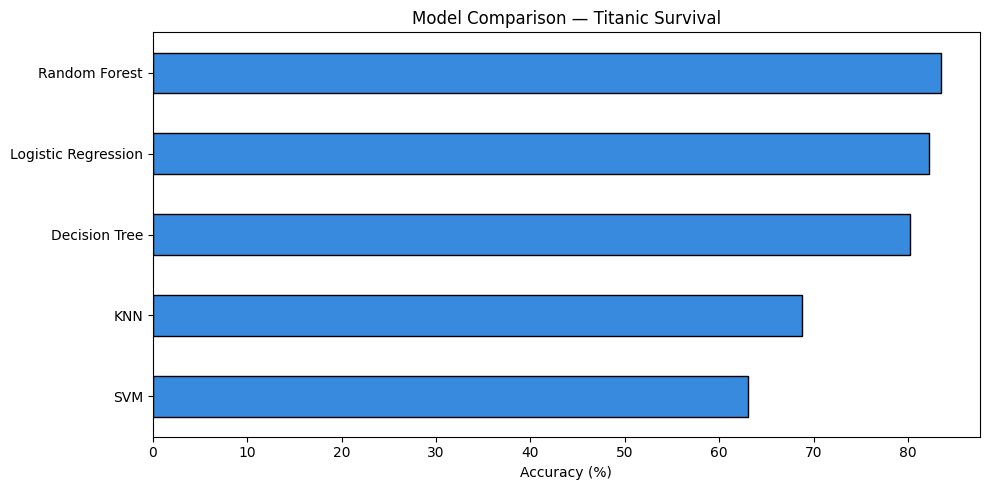

  Chart saved as model_comparison.png


In [ ]:
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm      import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics  import accuracy_score

models = {
    "Decision Tree":      DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42),
    "Random Forest":      RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":                SVC(kernel="rbf", probability=True, random_state=42),
    "KNN":                KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = round(acc * 100, 2)
    print(f"  {name:<25} Accuracy: {acc:.4f} ({acc*100:.2f}%)")

best_model_name = max(results, key=results.get)
best_model      = models[best_model_name]
print(f"\n  Best model: {best_model_name} ({results[best_model_name]}%)")

# Plot model comparison
plt.figure(figsize=(10, 5))
pd.Series(results).sort_values().plot(
    kind="barh", color="#378ADD", edgecolor="black"
)
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison — Titanic Survival")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("  Chart saved as model_comparison.png")


 STEP 7 — DECISION TREE WITH PRUNING

In [ ]:
# pahle too hmne decision tree without pruning creat kiya hii:---(NO pruning)
# abb hmm Decision tree with pree pruning creat karenge:---

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Pre-pruning: find best max_depth
print("  Pre-pruning — testing depths:")
best_depth_acc = 0
best_depth     = 1
for depth in range(1, 11):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = m.score(X_test, y_test)
    print(f"    Depth={depth}  Accuracy={acc:.4f}")
    if acc > best_depth_acc:
        best_depth_acc = acc
        best_depth     = depth

print(f"  Best depth: {best_depth}  Accuracy: {best_depth_acc:.4f}")

  Pre-pruning — testing depths:
    Depth=1  Accuracy=0.8153
    Depth=2  Accuracy=0.7643
    Depth=3  Accuracy=0.8344
    Depth=4  Accuracy=0.7962
    Depth=5  Accuracy=0.8153
    Depth=6  Accuracy=0.7898
    Depth=7  Accuracy=0.7834
    Depth=8  Accuracy=0.8025
    Depth=9  Accuracy=0.7834
    Depth=10  Accuracy=0.8025
  Best depth: 3  Accuracy: 0.8344


In [ ]:
# Post-pruning: cost complexity
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)
path       = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

best_alpha = 0
best_acc   = 0
for alpha in ccp_alphas:
    m = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    m.fit(X_train, y_train)
    acc = m.score(X_test, y_test)
    if acc > best_acc:
        best_acc   = acc
        best_alpha = alpha

print(f"  Post-pruning best alpha: {best_alpha:.6f}  Accuracy: {best_acc:.4f}")

  Post-pruning best alpha: 0.003807  Accuracy: 0.8408


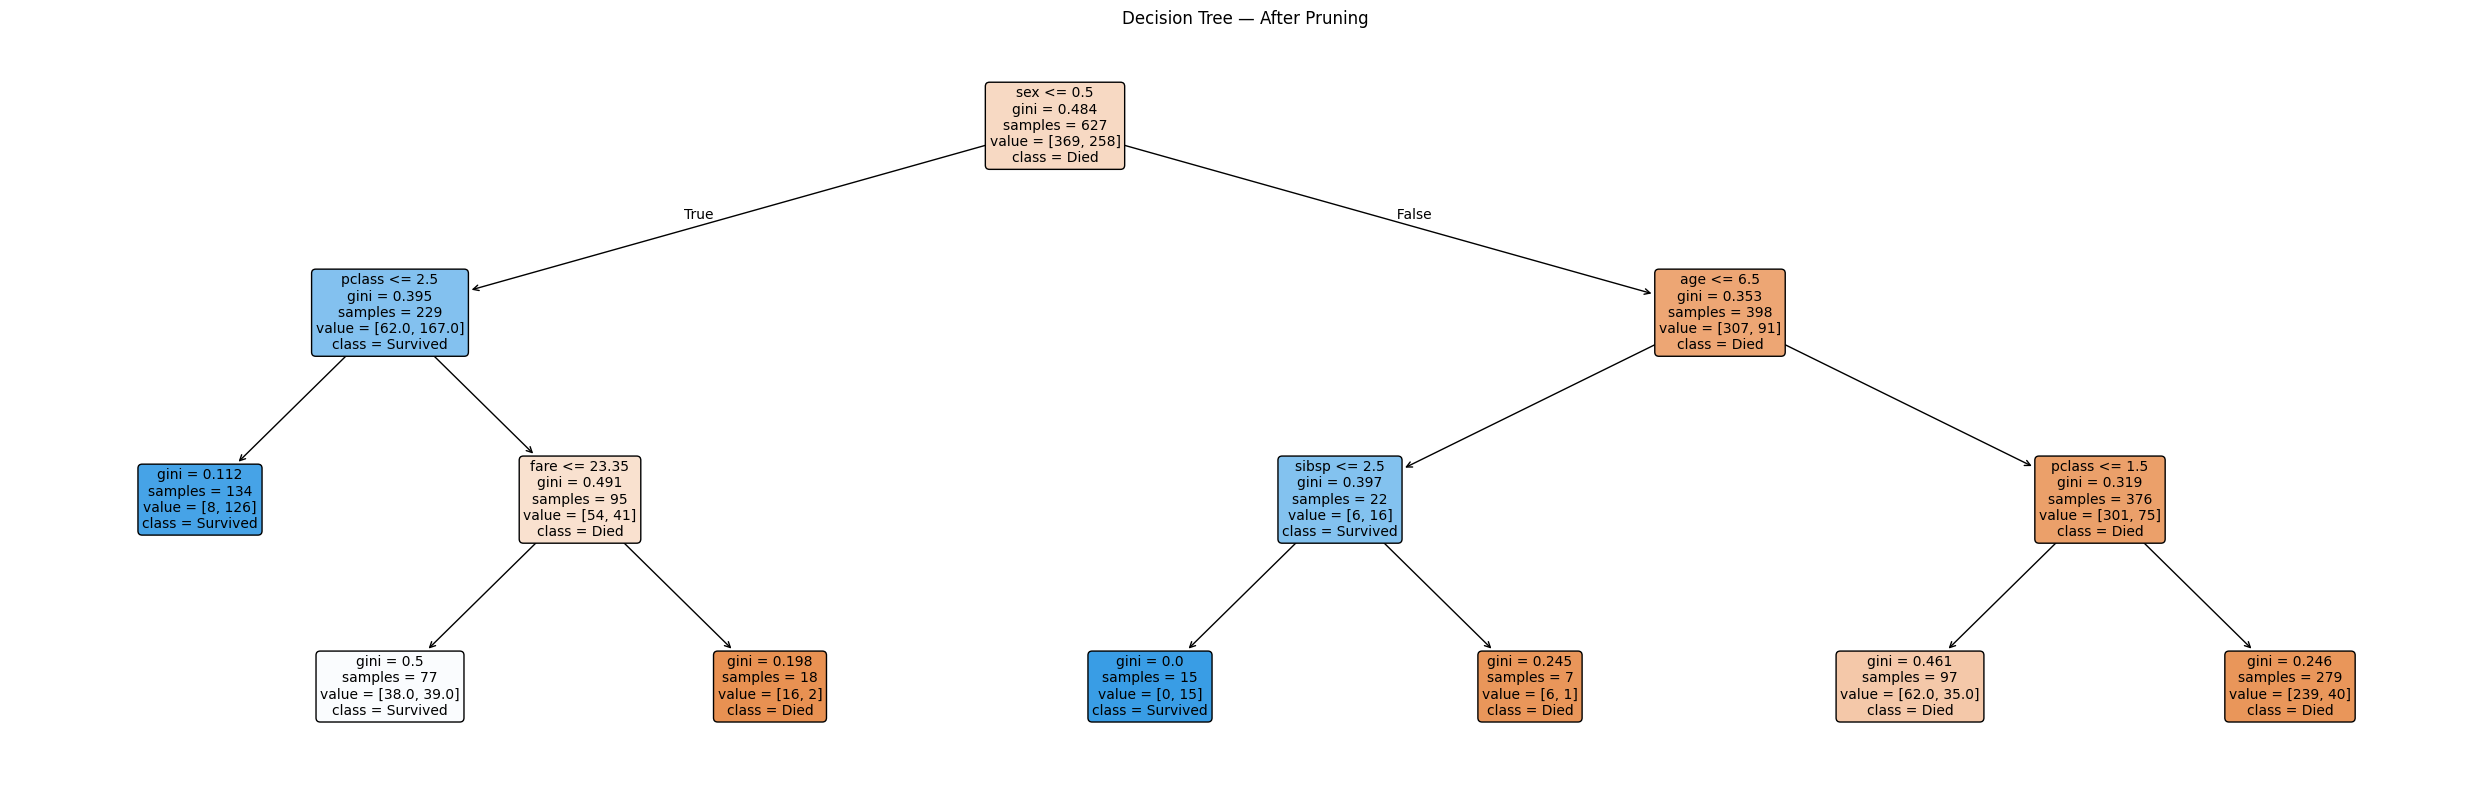

  Tree saved as decision_tree_pruned.png


In [ ]:
# Final pruned decision tree
pruned_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    ccp_alpha=best_alpha,
    random_state=42
)
pruned_dt.fit(X_train, y_train)

# Visualise tree
plt.figure(figsize=(25, 8))
plot_tree(
    pruned_dt,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree — After Pruning")
plt.tight_layout()
plt.savefig("decision_tree_pruned.png", dpi=100, bbox_inches="tight")
plt.show()
print("  Tree saved as decision_tree_pruned.png")

STEP 8 — FULL MODEL EVALUATION

In [ ]:
print("\n[STEP 8] Evaluating best model...")


[STEP 8] Evaluating best model...


In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.model_selection import cross_val_score

y_pred = best_model.predict(X_test)


In [ ]:
# Classification report
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))



  Classification Report:
              precision    recall  f1-score   support

        Died       0.83      0.90      0.86        92
    Survived       0.84      0.74      0.79        65

    accuracy                           0.83       157
   macro avg       0.84      0.82      0.83       157
weighted avg       0.84      0.83      0.83       157



Text(0.5, 1.0, 'Confusion Matrix — Random Forest')

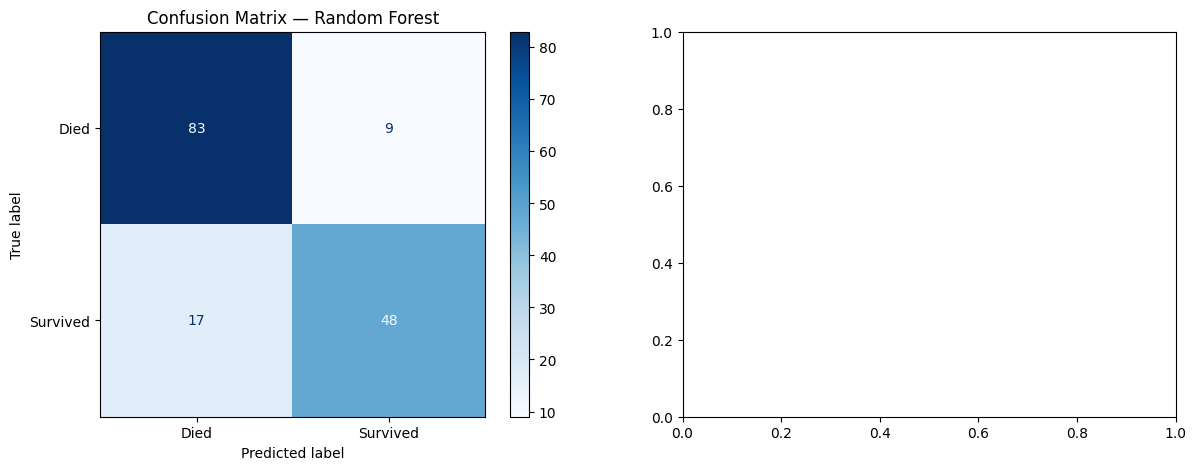

In [ ]:
# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

In [ ]:
# ROC Curve
y_prob    = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc   = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1], color="gray", lw=1, linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"  ROC AUC Score: {roc_auc:.4f}")


<Figure size 640x480 with 0 Axes>

  ROC AUC Score: 0.8701


In [ ]:
# Cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="accuracy")
print(f"\n  5-Fold CV Scores : {cv_scores}")
print(f"  Mean Accuracy    : {cv_scores.mean():.4f}")
print(f"  Std Deviation    : {cv_scores.std():.4f}")



  5-Fold CV Scores : [0.69426752 0.78980892 0.79617834 0.75796178 0.79487179]
  Mean Accuracy    : 0.7666
  Std Deviation    : 0.0388


STEP 9 — FEATURE IMPORTANCE

In [ ]:
print("\n[STEP 9] Feature importance...")


[STEP 9] Feature importance...


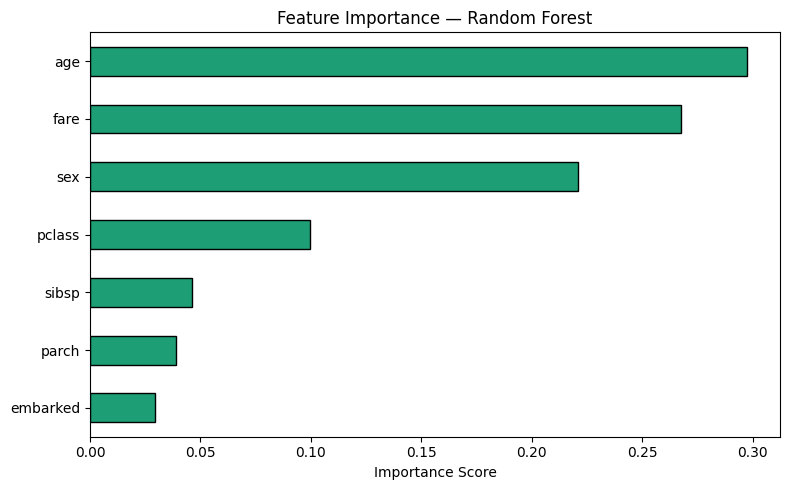

age         0.297530
fare        0.267381
sex         0.221088
pclass      0.099433
sibsp       0.046347
parch       0.038764
embarked    0.029456
dtype: float64


In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="#1D9E75", edgecolor="black")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(importances.sort_values(ascending=False))
else:
    print("  Feature importance not available for this model type.")


STEP 10 — SAVE MODEL LOCALLY

In [ ]:
print("\n[STEP 10] Saving model...")


[STEP 10] Saving model...


In [ ]:
joblib.dump(best_model, "model.joblib")
print("  model.joblib saved!")

  model.joblib saved!


In [ ]:
#  Quick verify
loaded = joblib.load("model.joblib")
verify = accuracy_score(y_test, loaded.predict(X_test))
print(f"  Loaded model accuracy: {verify:.4f} ")

  Loaded model accuracy: 0.8344 


STEP 11 — UPLOAD MODEL TO GCS BUCKET

In [ ]:
print("\n[STEP 11] Uploading model to GCS...")


[STEP 11] Uploading model to GCS...


In [ ]:
# Replace with your actual bucket name
GCS_BUCKET  = "titanic_123"
PROJECT_ID  = "titanic-498313"
REGION      = "us-central1"

try:
    from google.cloud import storage

    client = storage.Client(project=PROJECT_ID)
    bucket = client.bucket(GCS_BUCKET)
    blob   = bucket.blob("titanic-model/model.joblib")
    blob.upload_from_filename("model.joblib")
    print(f"  Uploaded to gs://{GCS_BUCKET}/titanic-model/model.joblib ✅")

except Exception as e:
    print(f"  GCS upload skipped (run in GCP environment): {e}")


  GCS upload skipped (run in GCP environment): 404 POST https://storage.googleapis.com/upload/storage/v1/b/titanic_123/o?uploadType=multipart: {
  "error": {
    "code": 404,
    "message": "The specified bucket does not exist.",
    "errors": [
      {
        "message": "The specified bucket does not exist.",
        "domain": "global",
        "reason": "notFound"
      }
    ]
  }
}
: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>)


STEP 12 — SAVE DATA TO BIGQUERY

In [ ]:
print("\n[STEP 12] Saving data to BigQuery...")



[STEP 12] Saving data to BigQuery...


In [ ]:
from google.cloud import bigquery

# Use your active Project ID
PROJECT_ID = "titanic-498313"

try:
    bq_client = bigquery.Client(project=PROJECT_ID)

    # Create dataset if it doesn't exist
    # Note: 'exists_ok=True' prevents an error if the dataset already exists
    dataset_id = f"{PROJECT_ID}.titanic_dataset"

    bq_client.create_dataset(dataset_id, exists_ok=True)
    print(f"Dataset ready: {dataset_id}")

except Exception as e:
    print(f"Error initializing BigQuery client or creating dataset: {e}")


Dataset ready: titanic-498313.titanic_dataset


In [ ]:
from google.cloud import bigquery

# Ensure PROJECT_ID is defined
PROJECT_ID = "titanic-498313"

# Define table ID and configuration
table_id = f"{PROJECT_ID}.titanic_dataset.cleaned_data"
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

# Prepare the dataframe for upload
df_upload = df.copy()
df_upload["split"] = "unknown"
df_upload.loc[X_train.index, "split"] = "train"
df_upload.loc[X_test.index,  "split"] = "test"

# Run the upload job
job = bq_client.load_table_from_dataframe(
    df_upload, table_id, job_config=job_config
)
job.result()  # Wait for the job to finish

print(f"Cleaned data uploaded to BigQuery: {table_id} ")


Cleaned data uploaded to BigQuery: titanic-498313.titanic_dataset.cleaned_data 


In [ ]:
from google.cloud import bigquery

# Ensure your Project ID is set
PROJECT_ID = "titanic-498313"
bq_client = bigquery.Client(project=PROJECT_ID)

try:
    # 1. Prepare Predictions DataFrame
    preds_df = X_test.copy()
    preds_df["actual_survived"]    = y_test.values
    preds_df["predicted_survived"] = y_pred
    preds_df["correct"]            = (preds_df["actual_survived"] == preds_df["predicted_survived"])
    preds_df["model_name"]         = best_model_name

    # 2. Define Table ID
    pred_table_id = f"{PROJECT_ID}.titanic_dataset.model_predictions"

    # 3. Upload to BigQuery
    job2 = bq_client.load_table_from_dataframe(
        preds_df,
        pred_table_id,
        job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    )
    job2.result() # Wait for completion

    print(f"Predictions uploaded to BigQuery: {pred_table_id} ✅")

except Exception as e:
    print(f"BigQuery upload failed: {e}")


Predictions uploaded to BigQuery: titanic-498313.titanic_dataset.model_predictions ✅


STEP 13 — REGISTER MODEL IN VERTEX AI

In [ ]:
print("\n[STEP 13] Registering model in Vertex AI...")



[STEP 13] Registering model in Vertex AI...


Step 1: Upload the model to the correct bucket

In [ ]:
from google.cloud import storage
import joblib

# 1. Save your model locally first
# Replace 'your_model_variable' with your trained model (e.g., best_model)
joblib.dump(best_model, 'model.joblib')

# 2. Upload to the verified bucket: titanic1bucket
PROJECT_ID = "titanic-498313"
GCS_BUCKET = "titanic1bucket"

storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(GCS_BUCKET)
blob = bucket.blob("titanic-model/model.joblib")
blob.upload_from_filename("model.joblib")

print(f"✅ Model uploaded to: gs://{GCS_BUCKET}/titanic-model/model.joblib")


✅ Model uploaded to: gs://titanic1bucket/titanic-model/model.joblib


Step 2: Register the Model
Now that the path exists, run the registration code:

In [ ]:
from google.cloud import aiplatform

PROJECT_ID = "titanic-498313"
REGION = "us-central1"
GCS_BUCKET = "titanic1bucket" # Updated to the correct name

aiplatform.init(project=PROJECT_ID, location=REGION)

try:
    model = aiplatform.Model.upload(
        display_name="titanic-survival-model",
        artifact_uri=f"gs://{GCS_BUCKET}/titanic-model/",
        serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest",
        sync=True
    )
    print(f"Model registered: {model.resource_name} ✅")
except Exception as e:
    print(f"Failed to register model: {e}")


Model registered: projects/638658038035/locations/us-central1/models/4715198990868545536 ✅


In [ ]:
from google.cloud import aiplatform

# Ensure your variables are defined
PROJECT_ID = "titanic-498313"
REGION = "us-central1"  # Or your specific region
GCS_BUCKET = "titanic1bucket"

# Initialize the Vertex AI SDK
aiplatform.init(project=PROJECT_ID, location=REGION)

try:
    # Register the model in Vertex AI Model Registry
    model = aiplatform.Model.upload(
        display_name="titanic-survival-model",
        artifact_uri=f"gs://{GCS_BUCKET}/titanic-model/",
        serving_container_image_uri=(
            "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest"
        ),
        sync=True
    )
    print(f"Model registered successfully: {model.resource_name} ✅")

except Exception as e:
    print(f"Failed to register model in Vertex AI: {e}")


Model registered successfully: projects/638658038035/locations/us-central1/models/2319283989107441664 ✅


(2ns way for Model registered successfully: Upload your model file to GCS)

In [ ]:
from google.cloud import storage
import joblib

# 1. Save your model locally
joblib.dump(best_model, 'model.joblib')

# 2. Upload to your actual bucket: titanic1bucket
bucket_name = "titanic1bucket"
storage_client = storage.Client()
bucket = storage_client.bucket(bucket_name)
blob = bucket.blob("titanic-model/model.joblib")
blob.upload_from_filename("model.joblib")

print(f"Model file uploaded to gs://{bucket_name}/titanic-model/model.joblib")


Model file uploaded to gs://titanic1bucket/titanic-model/model.joblib


Run the Model Registry code with the correct bucket

In [ ]:
from google.cloud import aiplatform

PROJECT_ID = "titanic-498313"
REGION = "us-central1"
GCS_BUCKET = "titanic1bucket" # Use the verified bucket name

aiplatform.init(project=PROJECT_ID, location=REGION)

try:
    model = aiplatform.Model.upload(
        display_name="titanic-survival-model",
        # Point to the folder containing model.joblib
        artifact_uri=f"gs://{GCS_BUCKET}/titanic-model/",
        serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest",
        sync=True
    )
    print(f"Model registered: {model.resource_name} ✅")
except Exception as e:
    print(f"Registration failed: {e}")


Model registered: projects/638658038035/locations/us-central1/models/1459202013395943424 ✅


In [ ]:
import joblib

# Force protocol 4 for compatibility
joblib.dump(best_model, 'model.joblib', protocol=4)


['model.joblib']

In [ ]:
# Use 1-2 or latest instead of 1-0
serving_container_image_uri = "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-2:latest"


In [ ]:
from google.cloud import aiplatform

# Ensure AI Platform is initialized
PROJECT_ID = "titanic-498313"
REGION = "us-central1"
aiplatform.init(project=PROJECT_ID, location=REGION)

try:
  # Create endpoint
    endpoint = aiplatform.Endpoint.create(
        display_name="titanic-endpoint",
        sync=True
    )
    print(f"  Endpoint created: {endpoint.resource_name}")

    # Deploy model (~10-15 minutes)
    model.deploy(
        endpoint=endpoint,
        deployed_model_display_name="titanic-v1",
        machine_type="n1-standard-2",
        min_replica_count=1,
        max_replica_count=1,
        sync=True
    )
    print(f"  Model deployed to endpoint ✅")
    print(f"  Endpoint ID: {endpoint.name}")

except Exception as e:
    print(f"  Vertex AI skipped (run in GCP environment): {e}")

  Endpoint created: projects/638658038035/locations/us-central1/endpoints/129874863228715008
  Vertex AI skipped (run in GCP environment): 400 Model server never became ready. Please validate that your model file or container configuration are valid. Model server logs can be found at https://console.cloud.google.com/logs/viewer?project=638658038035&resource=aiplatform.googleapis.com%2FEndpoint&advancedFilter=resource.type%3D%22aiplatform.googleapis.com%2FEndpoint%22%0Aresource.labels.endpoint_id%3D%22129874863228715008%22%0Aresource.labels.location%3D%22us-central1%22. 9: Model server never became ready. Please validate that your model file or container configuration are valid. Model server logs can be found at https://console.cloud.google.com/logs/viewer?project=638658038035&resource=aiplatform.googleapis.com%2FEndpoint&advancedFilter=resource.type%3D%22aiplatform.googleapis.com%2FEndpoint%22%0Aresource.labels.endpoint_id%3D%22129874863228715008%22%0Aresource.labels.location%3D%22us-c

In [ ]:
from google.cloud import aiplatform

# Ensure AI Platform is initialized
PROJECT_ID = "titanic-498313"
REGION = "us-central1"
aiplatform.init(project=PROJECT_ID, location=REGION)

try:
    # 1. Create the Endpoint
    # This acts as the "address" where your model will live
    endpoint = aiplatform.Endpoint.create(
        display_name="titanic-endpoint",
        sync=True
    )
    print(f"Endpoint created: {endpoint.resource_name} ✅")

    # 2. Deploy the Model to the Endpoint
    # This connects your registered model to the endpoint you just created
    model.deploy(
        endpoint=endpoint,
        machine_type="n1-standard-2", # Standard machine for predictions
        min_replica_count=1,
        max_replica_count=1,
        sync=True
    )
    print("Model successfully deployed to endpoint! 🚀")

except Exception as e:
    print(f"An error occurred: {e}")


Endpoint created: projects/638658038035/locations/us-central1/endpoints/4371139812304879616 ✅
An error occurred: 400 Model server never became ready. Please validate that your model file or container configuration are valid. Model server logs can be found at https://console.cloud.google.com/logs/viewer?project=638658038035&resource=aiplatform.googleapis.com%2FEndpoint&advancedFilter=resource.type%3D%22aiplatform.googleapis.com%2FEndpoint%22%0Aresource.labels.endpoint_id%3D%224371139812304879616%22%0Aresource.labels.location%3D%22us-central1%22. 9: Model server never became ready. Please validate that your model file or container configuration are valid. Model server logs can be found at https://console.cloud.google.com/logs/viewer?project=638658038035&resource=aiplatform.googleapis.com%2FEndpoint&advancedFilter=resource.type%3D%22aiplatform.googleapis.com%2FEndpoint%22%0Aresource.labels.endpoint_id%3D%224371139812304879616%22%0Aresource.labels.location%3D%22us-central1%22.


STEP 14 — TEST LIVE PREDICTIONS

In [ ]:
print("\n[STEP 14] Testing predictions on new passengers...")



[STEP 14] Testing predictions on new passengers...


In [ ]:
# Format: [pclass, sex(0=female,1=male), age, sibsp, parch, fare, embarked(C=0,Q=1,S=2)]
new_passengers = pd.DataFrame({
    "pclass":   [3,    1,    2],
    "sex":      [1,    0,    0],
    "age":      [22,   38,   26],
    "sibsp":    [1,    1,    0],
    "parch":    [0,    0,    0],
    "fare":     [7.25, 71.28, 13.0],
    "embarked": [2,    0,    0],
})

descriptions = [
    "3rd class male, 22yo  ",
    "1st class female, 38yo",
    "2nd class female, 26yo",
]

preds = loaded.predict(new_passengers)
probs = loaded.predict_proba(new_passengers)

print(f"\n  {'Passenger':<28} {'Result':<20} {'Confidence'}")
print("  " + "-" * 58)
for i, (pred, prob, desc) in enumerate(zip(preds, probs, descriptions)):
    status     = "✅ Survived" if pred == 1 else "❌ Did Not Survive"
    confidence = max(prob) * 100
    print(f"  {desc}  {status:<20} {confidence:.1f}%")



  Passenger                    Result               Confidence
  ----------------------------------------------------------
  3rd class male, 22yo    ❌ Did Not Survive    87.4%
  1st class female, 38yo  ✅ Survived           100.0%
  2nd class female, 26yo  ✅ Survived           91.2%


In [ ]:
import pyspark

if pyspark.__version__ < '4.0.0':
    print("Uninstalling existing PySpark versions and installing PySpark 4.0...")
    !pip uninstall -y dataproc-spark-connect pyspark pyspark-stub
    !pip install git+https://github.com/GoogleCloudDataproc/dataproc-spark-connect-python.git@v1.0.0rc1
    print("PySpark 4.0 installed.")
else:
    print(f"PySpark version {pyspark.__version__} is already installed.")

In [ ]:
from google.cloud.dataproc_spark_connect import DataprocSparkSession
from google.cloud.dataproc_v1 import Session

session = Session()
session.runtime_config.version = "3.0"

spark = (
    DataprocSparkSession.builder
      .appName("CustomSparkSession")
      .dataprocSessionConfig(session)
      .getOrCreate()
)

print("Spark session initialized.")

STEP 15 — BIGQUERY SQL QUERIES TO RUN